### DATA EXPLORATION

Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub as kh
import os

from sklearn.model_selection import train_test_split

Load the dataset

In [ ]:
path = kh.dataset_download("rabieelkharoua/alzheimers-disease-dataset")
print("Path to dataset files:", path)

files = os.listdir(path)
print("Files in directory:", files)

csv_file = [f for f in files if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)


df = pd.read_csv(csv_path)
print("Shape:", df.shape)
df.head()

Basic overview

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64  
 14  Dep

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Check for missing values

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

Series([], dtype: int64)

Class distribution

In [5]:
df['Diagnosis'].value_counts()
df['Diagnosis'].value_counts(normalize=True)

Diagnosis
0    0.646347
1    0.353653
Name: proportion, dtype: float64

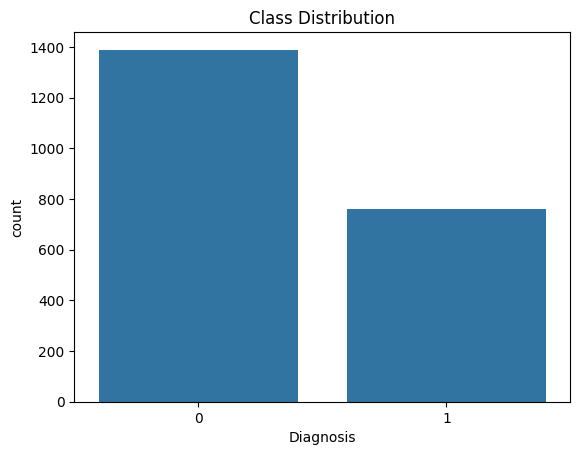

In [6]:
sns.countplot(x='Diagnosis', data=df)
plt.title("Class Distribution")
plt.show()

Drop irrelevant columns

In [7]:
df = df.drop(columns=['PatientID', 'DoctorInCharge'], errors='ignore')

Separate feature types

In [8]:
binary_cols = [
    'Gender', 'Smoking', 'FamilyHistoryAlzheimers', 
    'CardiovascularDisease', 'Diabetes', 'Depression',
    'HeadInjury', 'Hypertension',
    'MemoryComplaints', 'BehavioralProblems',
    'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks',
    'Forgetfulness'
]

categorical_cols = ['Ethnicity', 'EducationLevel']

target_col = 'Diagnosis'

numeric_cols = [col for col in df.columns 
                if col not in binary_cols + categorical_cols + [target_col]]

Verify

In [9]:
print("Numeric:", numeric_cols)
print("Binary:", binary_cols)
print("Categorical:", categorical_cols)

Numeric: ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']
Binary: ['Gender', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']
Categorical: ['Ethnicity', 'EducationLevel']


Correlation Matrix

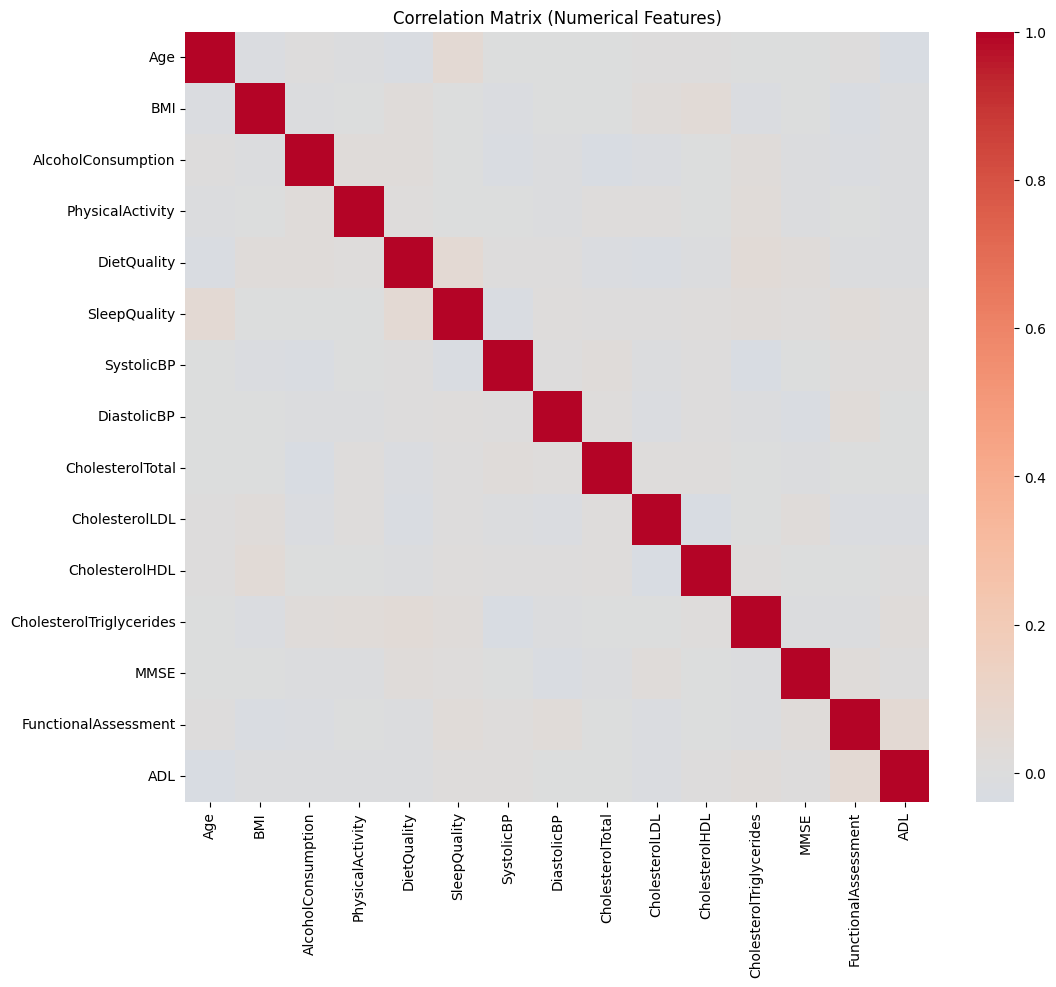

In [10]:
plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', center=0)
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

#### FEATURE VS TARGET

Age vs. Diagnosis

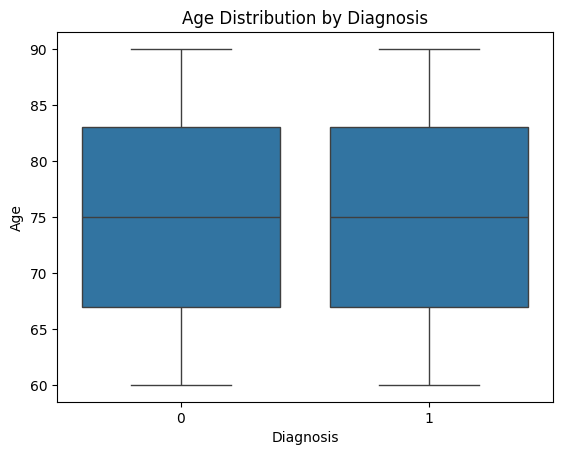

In [11]:
sns.boxplot(x='Diagnosis', y='Age', data=df)
plt.title("Age Distribution by Diagnosis")
plt.show()

MMSE vs Diagnosis

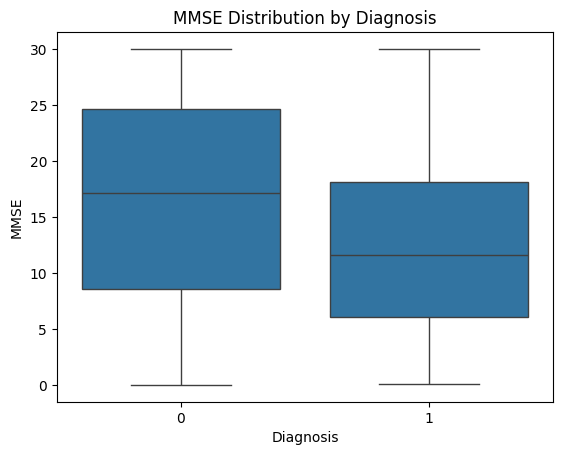

In [12]:
sns.boxplot(x='Diagnosis', y='MMSE', data=df)
plt.title("MMSE Distribution by Diagnosis")
plt.show()

Quick statistaical comparison

In [13]:
df.groupby('Diagnosis')[numeric_cols].mean()

,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,ADL
Diagnosis,,,,,,,,,,,,,,,
0,74.945284,27.515092,10.071880,4.90764,4.974839,7.124832,134.564435,89.778978,224.996342,125.361434,58.734832,226.571537,16.265543,5.860669,5.707951
1,74.842105,27.912670,9.980156,4.94316,5.026581,6.916292,133.717105,89.973684,225.565197,122.461726,60.795330,231.406671,11.994657,3.653380,3.657938


Prepare Data for Modeling

In [14]:
X = df.drop(columns=[target_col])
y = df[target_col]

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Final feature shape:", X.shape)

Final feature shape: (2149, 36)


Train/Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1719, 36)
Test shape: (430, 36)


Scale Features

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression Baseline

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       278
           1       0.69      0.85      0.76       152

    accuracy                           0.81       430
   macro avg       0.80      0.82      0.80       430
weighted avg       0.83      0.81      0.81       430

ROC-AUC: 0.8833775085195001
Confusion Matrix:
 [[219  59]
 [ 23 129]]


Random Forest Baseline

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       278
           1       0.94      0.88      0.91       152

    accuracy                           0.94       430
   macro avg       0.94      0.92      0.93       430
weighted avg       0.94      0.94      0.94       430

ROC-AUC: 0.9376774895872775
Confusion Matrix:
 [[270   8]
 [ 19 133]]


Compare ROC Curves

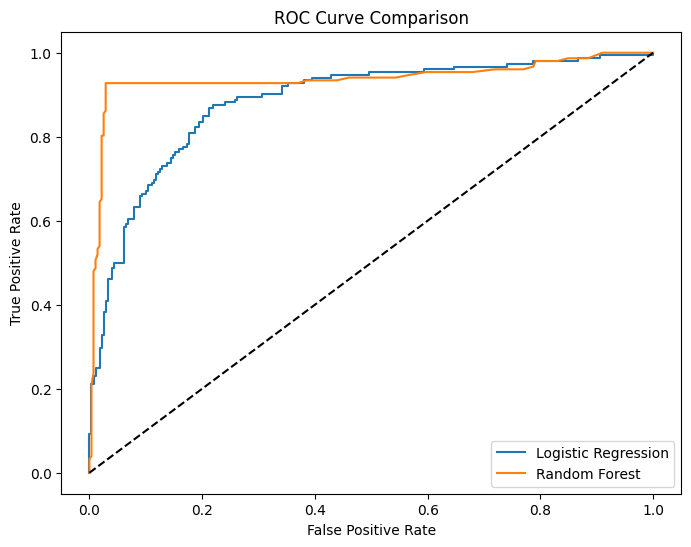

In [19]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

Logistic Regression Coefficients. 
Shows which features increase or decrease Alzheimer risk according to logistic regression.

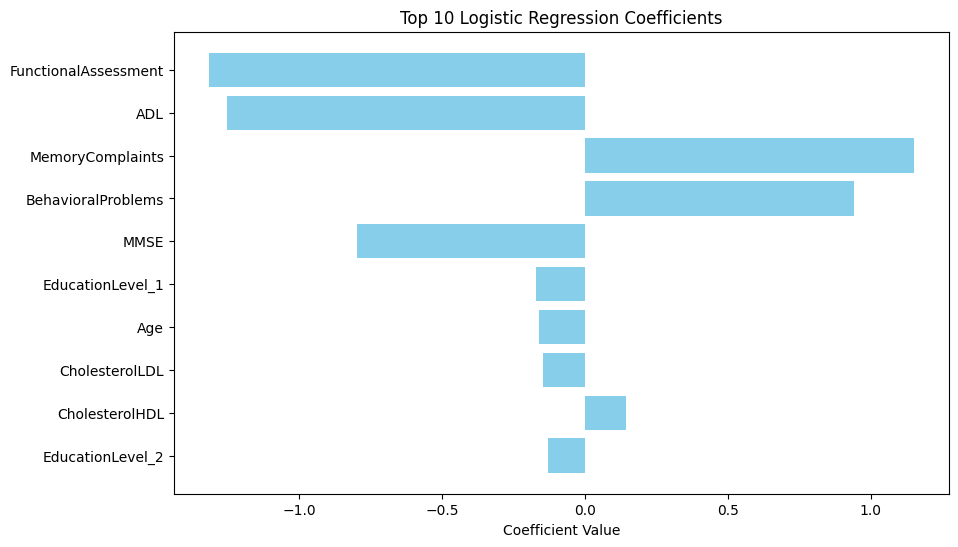

In [20]:
# Get feature names after one-hot encoding
feature_names = X_train.columns

# Coefficients
coefficients = log_reg.coef_[0]

# Create DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'AbsCoefficient': np.abs(coefficients)
})

# Sort by absolute value
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

# Top 10 features
top_coef_df = coef_df.head(10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top_coef_df['Feature'][::-1], top_coef_df['Coefficient'][::-1], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Top 10 Logistic Regression Coefficients')
plt.show()

Random Forest Feature Importance. Gives a global view of what RF finds important.

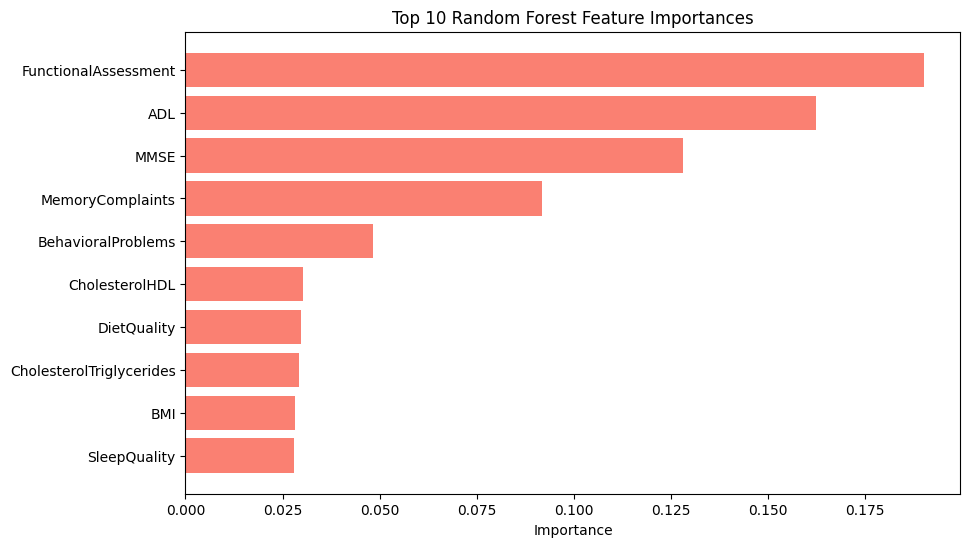

In [21]:
# Feature importances
importances = rf.feature_importances_

# DataFrame
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# Top 10
top_rf_df = rf_importance_df.head(10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top_rf_df['Feature'][::-1], top_rf_df['Importance'][::-1], color='salmon')
plt.xlabel('Importance')
plt.title('Top 10 Random Forest Feature Importances')
plt.show()

SHAP Analysis (Random Forest).

Global insight: Which features drive the model most

Local insight: How individual feature values affect prediction

Visual comparison: Compare LR vs RF importance

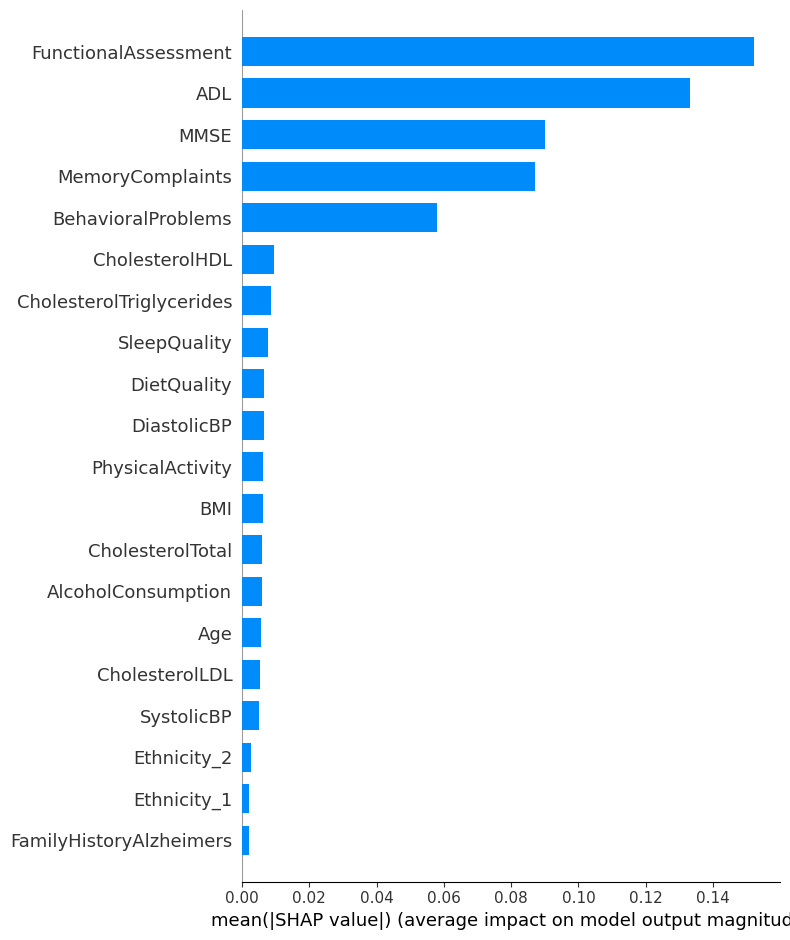

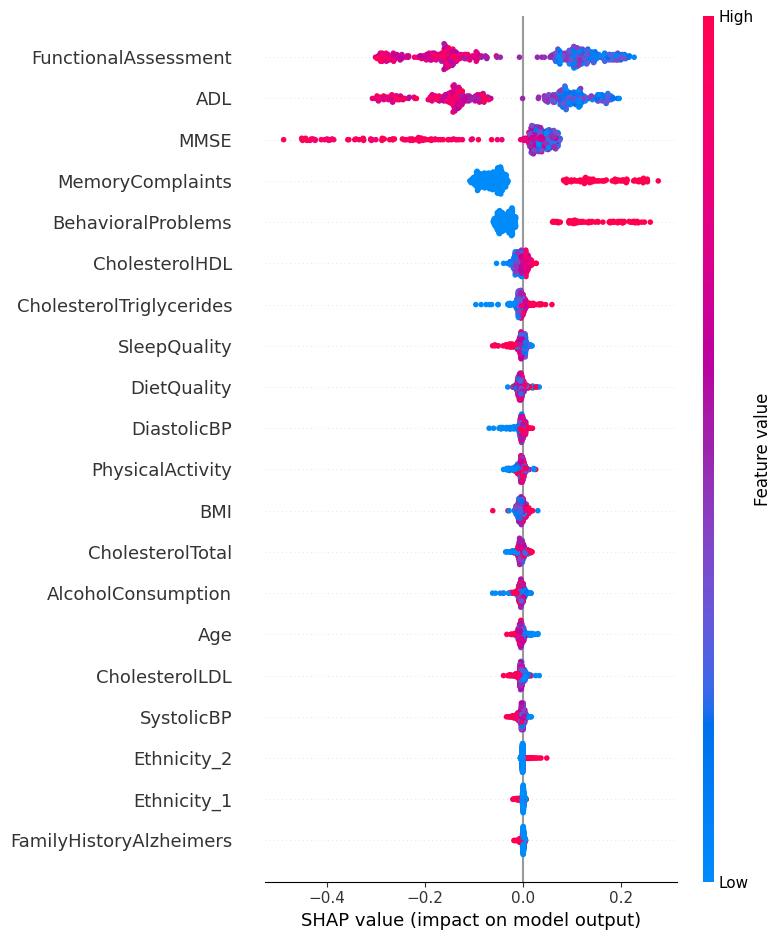

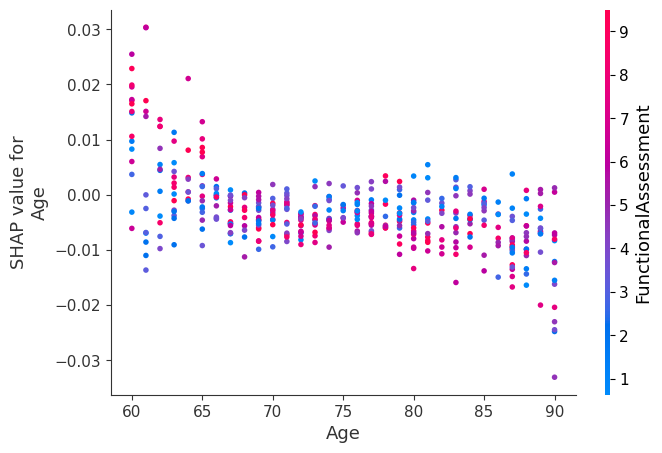

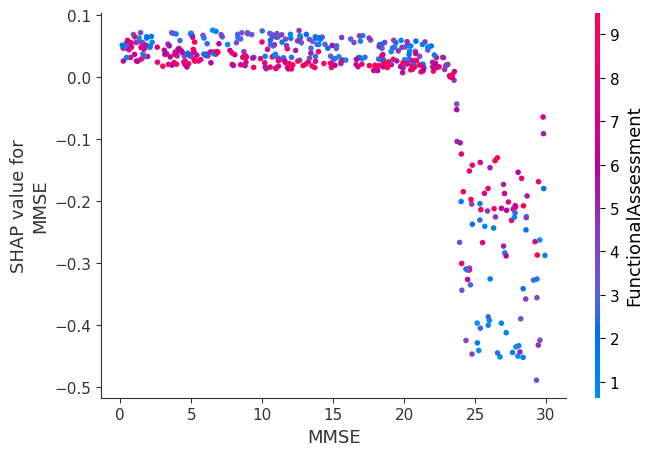

In [32]:
import shap

# Make sure X_test is a DataFrame
X_test_df = X_test.copy() if isinstance(X_test, pd.DataFrame) else pd.DataFrame(X_test, columns=X_train.columns)

# Create explainer
explainer = shap.TreeExplainer(rf)

# Compute SHAP values
try:
    # New SHAP versions return Explanation object
    shap_values_obj = explainer(X_test_df, check_additivity=False)
    shap_values = shap_values_obj.values[:, :, 1]  # select positive class
except:
    # Old SHAP version
    shap_values = explainer.shap_values(X_test_df)[1]

# Summary bar plot (global importance)
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

# Detailed summary plot
shap.summary_plot(shap_values, X_test_df)

# Dependence plot for Age
shap.dependence_plot("Age", shap_values, X_test_df)

# Dependence plot for MMSE
shap.dependence_plot("MMSE", shap_values, X_test_df)

Compare LR vs RF Features: Top predictive features across models.

In [33]:
# Merge top features for report discussion
comparison_df = pd.merge(
    top_coef_df[['Feature', 'Coefficient']],
    top_rf_df[['Feature', 'Importance']],
    on='Feature', how='outer'
).fillna(0)

print(comparison_df)

                     Feature  Coefficient  Importance
0                        ADL    -1.250141    0.162390
1                        Age    -0.160719    0.000000
2                        BMI     0.000000    0.028282
3         BehavioralProblems     0.941109    0.048387
4             CholesterolHDL     0.144154    0.030192
5             CholesterolLDL    -0.147161    0.000000
6   CholesterolTriglycerides     0.000000    0.029221
7                DietQuality     0.000000    0.029660
8           EducationLevel_1    -0.170729    0.000000
9           EducationLevel_2    -0.130162    0.000000
10      FunctionalAssessment    -1.313698    0.190097
11                      MMSE    -0.797677    0.128116
12          MemoryComplaints     1.150934    0.091870
13              SleepQuality     0.000000    0.027981


Reduced-Feature Experiment

In [34]:
# Features to exclude
exclude_cols = [
    'MMSE', 'ADL', 'FunctionalAssessment',
    'MemoryComplaints', 'BehavioralProblems',
    'Confusion', 'Disorientation', 'PersonalityChanges',
    'DifficultyCompletingTasks', 'Forgetfulness'
]

X_reduced = X.drop(columns=exclude_cols, errors='ignore')

# Train/test split
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)

# Scale numeric features for LR
numeric_cols_red = [col for col in X_train_red.columns if col not in binary_cols + categorical_cols]
scaler_red = StandardScaler()
X_train_red_scaled = scaler_red.fit_transform(X_train_red)
X_test_red_scaled = scaler_red.transform(X_test_red)

Logistic Regression (Reduced Features)

In [35]:
log_reg_red = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_reg_red.fit(X_train_red_scaled, y_train_red)
y_pred_lr_red = log_reg_red.predict(X_test_red_scaled)
y_prob_lr_red = log_reg_red.predict_proba(X_test_red_scaled)[:, 1]

print("Reduced-Feature Logistic Regression ROC-AUC:", roc_auc_score(y_test_red, y_prob_lr_red))
print(classification_report(y_test_red, y_pred_lr_red))

Reduced-Feature Logistic Regression ROC-AUC: 0.5183405906853464
              precision    recall  f1-score   support

           0       0.65      0.47      0.55       278
           1       0.36      0.54      0.43       152

    accuracy                           0.50       430
   macro avg       0.51      0.51      0.49       430
weighted avg       0.55      0.50      0.51       430



Random Forest (Reduced Features)

In [36]:
rf_red = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_red.fit(X_train_red, y_train_red)
y_pred_rf_red = rf_red.predict(X_test_red)
y_prob_rf_red = rf_red.predict_proba(X_test_red)[:, 1]

print("Reduced-Feature Random Forest ROC-AUC:", roc_auc_score(y_test_red, y_prob_rf_red))
print(classification_report(y_test_red, y_pred_rf_red))

Reduced-Feature Random Forest ROC-AUC: 0.4871142559636502
              precision    recall  f1-score   support

           0       0.65      0.98      0.78       278
           1       0.44      0.03      0.05       152

    accuracy                           0.64       430
   macro avg       0.55      0.50      0.42       430
weighted avg       0.58      0.64      0.52       430



5-Fold Cross-Validation

In [37]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression CV
lr_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print("Logistic Regression 5-Fold ROC-AUC:", lr_cv_scores.mean(), "+/-", lr_cv_scores.std())

# Random Forest CV
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')
print("Random Forest 5-Fold ROC-AUC:", rf_cv_scores.mean(), "+/-", rf_cv_scores.std())

Logistic Regression 5-Fold ROC-AUC: 0.9031145408000782 +/- 0.012681134228160258
Random Forest 5-Fold ROC-AUC: 0.9546588818047986 +/- 0.010877504825956416


Feature Significance / p-values

In [62]:
import statsmodels.api as sm

# Convert to numeric arrays
y_train_numeric = pd.to_numeric(y_train, errors='coerce').values.astype(float)
X_train_sm = sm.add_constant(X_train.values.astype(float))

# Check for NaN values
print(f"NaN values in y_train: {np.isnan(y_train_numeric).sum()}")
print(f"NaN values in X_train: {np.isnan(X_train_sm).sum()}")
print(f"y_train unique values: {np.unique(y_train_numeric)}")

model_sm = sm.Logit(y_train_numeric, X_train_sm)
result = model_sm.fit(disp=0)
print(result.summary())

NaN values in y_train: 0
NaN values in X_train: 0
y_train unique values: [0. 1.]
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1719
Model:                          Logit   Df Residuals:                     1682
Method:                           MLE   Df Model:                           36
Date:                Thu, 26 Feb 2026   Pseudo R-squ.:                  0.4501
Time:                        15:16:23   Log-Likelihood:                -614.16
converged:                       True   LL-Null:                       -1116.8
Covariance Type:            nonrobust   LLR p-value:                1.189e-187
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.7433      1.124      5.111      0.000       3.541       7.946
x1            -0.0162      0.008     -2.005      0